# 3. Entrenamiento de Modelo Surrogativo y SHAP

In [1]:
# %% Celda 1: Configuración e Importación de Librerías
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import itertools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import shap

# Variables globales modificables
FILE_PATTERN = "../outphys_beta_0403/*.csv"  # Patrón para localizar los CSV
CHUNKSIZE = 10000                      # Número de filas a leer por chunk
MAX_SAMPLE_SIZE = 200000               # Tamaño máximo del muestreo (reservoir)
TARGET_COL = "branching_ratio_h2_gaga"
PARAM_COLS = ['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12']
TEST_SIZE = 0.2                        # Proporción para test en train/test split
RANDOM_STATE = 42                      # Semilla para reproducibilidad


c:\Users\fbien.DESKTOP-6FMEAR7\Desktop\mlclassic_kosmos\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# %% Celda 2: Misión 1 – Recolección y Selección de la Muestra

class SampleCollector:
    def __init__(self, file_pattern, param_cols, target_col, chunksize, max_samples):
        self.file_pattern = file_pattern
        self.param_cols = param_cols
        self.target_col = target_col
        self.all_cols = param_cols + [target_col]
        self.chunksize = chunksize
        self.max_samples = max_samples
        self.files = glob.glob(file_pattern)
        self.reservoir = []  # Lista para almacenar la muestra
        self.total_records = 0

    def collect_sample(self):
        print(f"Archivos encontrados: {len(self.files)}")
        for f in self.files:
            print(f"Procesando archivo: {os.path.basename(f)}")
            try:
                for chunk in pd.read_csv(f, chunksize=self.chunksize):
                    # Verifica que existan las columnas requeridas
                    if not set(self.all_cols).issubset(chunk.columns):
                        print(f"  [!] Advertencia: El archivo {f} no tiene todas las columnas requeridas.")
                        continue
                    # Reemplaza infinitos por NaN
                    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
                    # Elimina filas con NaN en las columnas clave
                    valid_chunk = chunk.dropna(subset=self.all_cols)
                    # Aplica reservoir sampling para cada registro válido
                    for record in valid_chunk[self.all_cols].to_dict('records'):
                        self.total_records += 1
                        if self.total_records <= self.max_samples:
                            self.reservoir.append(record)
                        else:
                            s = random.randint(1, self.total_records)
                            if s <= self.max_samples:
                                idx = random.randint(0, self.max_samples - 1)
                                self.reservoir[idx] = record
            except Exception as e:
                print(f"Error al procesar {f}: {e}")
        # Convertir la lista de registros a DataFrame
        sample_df = pd.DataFrame(self.reservoir)
        print(f"Muestra recolectada: {sample_df.shape[0]} registros de {self.total_records} procesados.")
        return sample_df

# Ejecutar misión 1
collector = SampleCollector(FILE_PATTERN, PARAM_COLS, TARGET_COL, CHUNKSIZE, MAX_SAMPLE_SIZE)
sample_df = collector.collect_sample()


Archivos encontrados: 1
Procesando archivo: beta_explore.csv
Muestra recolectada: 16032 registros de 16032 procesados.


In [3]:
# Preprocesamiento y Preparación

df_sample = sample_df.copy()

# Separar las variables independientes y el target
X = df_sample[PARAM_COLS]
y = df_sample[TARGET_COL]

# Normalizar los parámetros
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 12825, Test size: 3207


Traininig de Modelo Sustituto

In [4]:
# %% Celda 4: Misión 3 – Entrenamiento del Modelo Sustituto

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error


# Entrenar un modelo de Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = rf_model.predict(X_test)

# Calcular métricas de desempeño
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Desempeño del Modelo Sustituto (Random Forest):")
print(f"  R²: {r2:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  MAPE: {mape:.4f}")


Desempeño del Modelo Sustituto (Random Forest):
  R²: 1.0000
  RMSE: 0.0000
  MAE: 0.0000
  MAPE: 0.0039


# SHAP
Interpretacion con SHAP

In [23]:
X_test.shape[0]

3207

In [24]:
# Definir el tamaño del subset, por ejemplo, 100 muestras
subset_size = 3207
# Seleccionar índices aleatorios sin reemplazo
indices_subset = np.random.choice(X_test.shape[0], size=subset_size, replace=False)
# Crear el subset de X_test
X_test_subset = X_test[indices_subset]

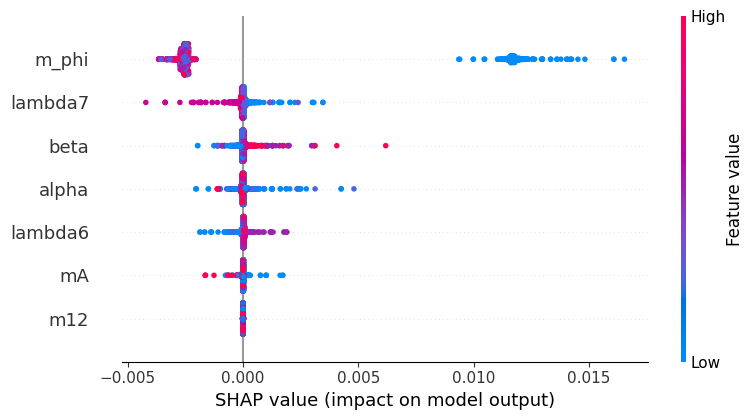

In [25]:
# Misión 4 – Interpretación con SHAP

# Crear el objeto explainer de SHAP usando TreeExplainer (optimizado para modelos basados en árboles)
explainer = shap.TreeExplainer(rf_model)

# Calcular los valores SHAP para el conjunto de prueba
shapev = explainer(X_test_subset) # explainer object
shap_values = shapev.values

# Gráfico summary de SHAP
shap.summary_plot(shap_values, X_test_subset, feature_names=PARAM_COLS)



In [29]:
# Suponiendo que X_test es tu conjunto de prueba normalizado y que 'scaler' es el objeto StandardScaler entrenado
X_test_original = scaler.inverse_transform(X_test)
X_test_subset_original = scaler.inverse_transform(X_test_subset)


# Si deseas obtener específicamente la columna 'm_phi' en su escala original:
# Encuentra el índice de 'm_phi' en la lista de columnas
m_phi_index = PARAM_COLS.index("m_phi")
m_phi_original = X_test_original[:, m_phi_index]

In [21]:
PARAM_COLS

['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12']

Generando dependencia para: m_phi


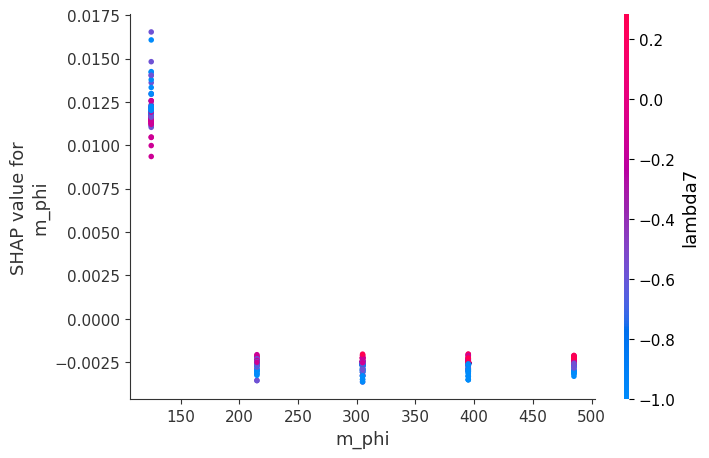

In [ ]:
# Ejemplo: gráfico de dependencia para el parámetro más influyente (puedes cambiar el índice)
most_influential_index = np.argmax(np.abs(shap_values).mean(0))

print(f"Generando dependencia para: {PARAM_COLS[most_influential_index]}")
shap.dependence_plot(most_influential_index, shap_values, X_test_subset_original, feature_names=PARAM_COLS)


In [27]:
X_test_subset_original.shape

(1500, 7)

In [28]:
shap_values.shape

(3207, 7)

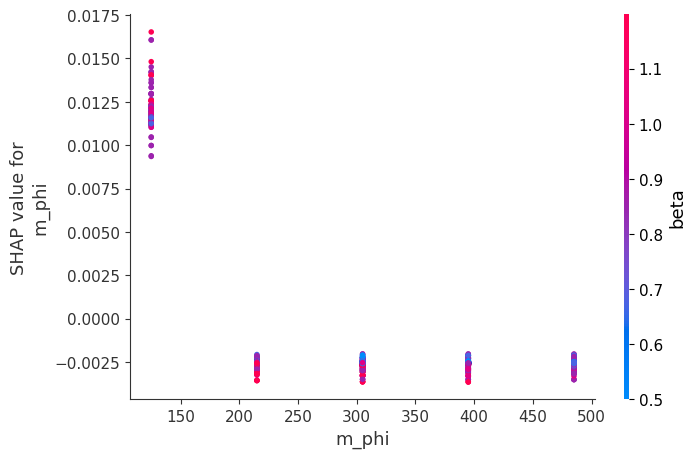

In [32]:
shap.dependence_plot(
    ind='m_phi',                        # eje X
    shap_values=shap_values,
    features=X_test_subset_original,
    feature_names=PARAM_COLS,
    interaction_index='beta'        # eje de color
)

Insights

In [9]:
# %% Celda 6: Misión 5 – Documentación y Análisis de Insights

print("Resumen de Insights del Modelo Sustituto:\n")
print("1. Rango de cada parámetro (según la muestra):")
for col in PARAM_COLS:
    col_data = df_sample[col]
    print(f"   {col}: [{col_data.min():.4g}, {col_data.max():.4g}]")
    
print("\n2. Desempeño del Modelo:")
print(f"   R²: {r2:.4f}")
print(f"   RMSE: {rmse:.4f}")

print("\n3. Hallazgos de SHAP:")
print("   Revisa los gráficos SHAP generados para identificar los parámetros de mayor impacto y posibles interacciones.")

# Opcional: Guardar insights en un archivo de texto
with open("insights_summary.txt", "w") as f:
    f.write("Resumen de Insights del Modelo Sustituto:\n\n")
    for col in PARAM_COLS:
        col_data = df_sample[col]
        f.write(f"{col}: min = {col_data.min():.4g}, max = {col_data.max():.4g}\n")
    f.write(f"\nDesempeño del Modelo:\n  R²: {r2:.4f}\n  RMSE: {rmse:.4f}\n")
    f.write("\nRevisa los gráficos SHAP generados para identificar parámetros críticos y posibles subespacios de interés.\n")
    
print("Resumen de insights guardado en 'insights_summary.txt'.")


Resumen de Insights del Modelo Sustituto:

1. Rango de cada parámetro (según la muestra):
   m_phi: [125, 485]
   mA: [320, 500]
   alpha: [-0.7, 0.7]
   beta: [0.5, 1.373]
   lambda6: [-1, 1.137]
   lambda7: [-1, 1.137]
   m12: [-1, 1.171]

2. Desempeño del Modelo:
   R²: 1.0000
   RMSE: 0.0000

3. Hallazgos de SHAP:
   Revisa los gráficos SHAP generados para identificar los parámetros de mayor impacto y posibles interacciones.
Resumen de insights guardado en 'insights_summary.txt'.


In [11]:
# %% Celda: Análisis de SHAP y Filtrado del Subespacio Crítico

import numpy as np
import pandas as pd

# --------------------- Parámetros Modificables ---------------------
NUM_BINS = 10  # Número de bins para agrupar el feature más influyente

# --------------------- Cálculo de Estadísticas Globales ---------------------
# Calcular la media de los valores absolutos de SHAP para cada feature
mean_shap = np.mean(np.abs(shap_values), axis=0)
print("Resumen de Mean |SHAP| por Feature:")
for idx, col in enumerate(PARAM_COLS):
    print(f"  {col}: {mean_shap[idx]:.4f}")

# Calcular percentiles (0, 25, 50, 75, 100) para cada feature
percentiles = [0, 25, 50, 75, 100]
shap_summary = {}
print("\nPercentiles de |SHAP| por Feature:")
for idx, col in enumerate(PARAM_COLS):
    col_shap = np.abs(shap_values[:, idx])
    shap_summary[col] = np.percentile(col_shap, percentiles)
    print(f"  {col}: {shap_summary[col]}")

# --------------------- Agrupación en Bins para el Feature Más Influyente ---------------------
# Se asume que 'most_influential_index' ya fue calculado previamente
most_influential_feature = PARAM_COLS[most_influential_index]
print(f"\nAnalizando por bins el feature más influyente: {most_influential_feature}")

# Convertir X_test_subset a DataFrame para facilitar la agrupación
df_features = pd.DataFrame(X_test_subset_original, columns=PARAM_COLS)
# Agregar columna con los SHAP values del feature más influyente
df_features[f"shap_{most_influential_feature}"] = shap_values[:, most_influential_index]

# Crear bins usando cuantiles (qcut)
try:
    df_features['bins'] = pd.qcut(df_features[most_influential_feature], q=NUM_BINS, duplicates='drop')
except ValueError as e:
    print("Error al crear bins:", e)
    df_features['bins'] = pd.cut(df_features[most_influential_feature], bins=NUM_BINS)

# Calcular la media de los SHAP values en cada bin
grouped_shap = df_features.groupby('bins')[f"shap_{most_influential_feature}"].mean()

# Imprimir de forma legible los rangos de cada bin y su SHAP promedio
print("\nMedia de SHAP values por bin:")
for interval, mean_val in grouped_shap.items():
    print(f"  Rango {interval}: Mean SHAP = {mean_val:.4f}")

# --------------------- Identificación del Bin Más Crítico ---------------------
# Se busca el bin con mayor valor absoluto de SHAP promedio
grouped_abs = grouped_shap.abs()
critical_bin = grouped_abs.idxmax()
critical_shap = grouped_shap.loc[critical_bin]
print(f"\nEl bin más influyente es: {critical_bin} con Mean SHAP = {critical_shap:.4f}")

# --------------------- Filtrado del Conjunto de Datos ---------------------
# Filtrar df_features para obtener solo los registros donde el feature más influyente
# se encuentre dentro del rango del bin crítico.
filtered_df = df_features[df_features[most_influential_feature].between(critical_bin.left, critical_bin.right, inclusive='left')]
print(f"\nCantidad de registros en el bin crítico ({critical_bin}): {filtered_df.shape[0]}")

# Mostrar estadísticas del subset filtrado (opcional)
print("\nEstadísticas del feature más influyente en el bin crítico:")
print(filtered_df[most_influential_feature].describe())

# Si deseas guardar el subset filtrado, descomenta la siguiente línea:
# filtered_df.to_csv("filtered_region.csv", index=False)


Resumen de Mean |SHAP| por Feature:
  m_phi: 0.0042
  mA: 0.0000
  alpha: 0.0001
  beta: 0.0001
  lambda6: 0.0001
  lambda7: 0.0001
  m12: 0.0000

Percentiles de |SHAP| por Feature:
  m_phi: [0.00204549 0.00252576 0.00255078 0.00265395 0.01653091]
  mA: [5.35148331e-10 1.24716471e-06 4.23407678e-06 1.19293000e-05
 1.71933964e-03]
  alpha: [3.71208827e-08 7.22092416e-06 1.83355559e-05 4.58167451e-05
 4.80441487e-03]
  beta: [1.09900830e-07 9.97418202e-06 1.90917995e-05 5.06218122e-05
 6.18217671e-03]
  lambda6: [1.35236090e-06 1.76557739e-05 2.33620084e-05 4.24020421e-05
 1.88896049e-03]
  lambda7: [3.01629831e-07 1.70892000e-05 3.42491516e-05 6.67942112e-05
 3.46090698e-03]
  m12: [1.34690777e-10 1.71037704e-08 4.06446078e-08 1.03545756e-07
 2.99433502e-05]

Analizando por bins el feature más influyente: m_phi

Media de SHAP values por bin:
  Rango (124.999, 215.0]: Mean SHAP = 0.0034
  Rango (215.0, 305.0]: Mean SHAP = -0.0026
  Rango (305.0, 395.0]: Mean SHAP = -0.0026
  Rango (395.0

C:\Users\fbien.DESKTOP-6FMEAR7\AppData\Local\temp\ipykernel_17900\1091819149.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_shap = df_features.groupby('bins')[f"shap_{most_influential_feature}"].mean()


## resultado principal

$m_\phi $: (124.999, 150.314] con Mean SHAP = 0.3323


In [33]:
# %% Celda: Análisis de la 2da variable en el subespacio crítico de m_phi

import numpy as np
import pandas as pd

# --- Supuestos:
# Se asume que ya se tiene:
# - X_test_subset: matriz (o array) con los datos de prueba en la escala normalizada.
# - X_test_subset_original: misma muestra en escala original (para m_phi y demás).
# - shap_values: matriz de SHAP values (calculados para X_test_subset).
# - PARAM_COLS: lista de nombres de variables.
# - critical_bin: intervalo crítico obtenido previamente para m_phi, por ejemplo:
#       critical_bin = pd.Interval(left=-1.8659999999999999, right=-1.541, closed='left')
# - most_influential_index: índice de m_phi (la variable más influyente).

# --- Paso 1: Filtrar la muestra para el rango crítico de m_phi en la escala original
# Convertir X_test_subset_original a DataFrame para facilitar el filtrado
df_test_orig = pd.DataFrame(X_test_subset_original, columns=PARAM_COLS)

# Crear una máscara para filtrar los registros cuyo m_phi esté dentro del intervalo crítico
mask_m_phi = df_test_orig["m_phi"].between(critical_bin.left, critical_bin.right, inclusive='left')
filtered_df = df_test_orig[mask_m_phi]

print(f"Registros en el rango crítico de m_phi {critical_bin}: {filtered_df.shape[0]}")

# --- Paso 2: Filtrar también los SHAP values correspondientes
# Se asume que el orden de las filas en X_test_subset_original coincide con el de X_test_subset y shap_values.
# Por ello, se genera la misma máscara a partir de la versión original.
filtered_shap = shap_values[mask_m_phi.values, :]  # Aseguramos que la máscara sea un array booleano

# --- Paso 3: Identificar la segunda variable más influyente en el subespacio filtrado
# Calcular la media de los valores absolutos de SHAP para cada feature, usando los datos filtrados.
mean_shap_filtered = np.mean(np.abs(filtered_shap), axis=0)

# Crear un DataFrame para ordenar las variables según su influencia
df_influence = pd.DataFrame({
    "feature": PARAM_COLS,
    "mean_abs_shap": mean_shap_filtered
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nRanking de variables por influencia en el subespacio crítico:")
print(df_influence)

# Asumimos que la primera es m_phi, la más influyente; la segunda es la segunda variable importante.
second_influential_feature = df_influence.loc[1, "feature"]
second_influential_index = PARAM_COLS.index(second_influential_feature)
print(f"\nLa segunda variable más influyente es: {second_influential_feature}")

# --- Paso 4: Agrupar la segunda variable en bins y calcular el promedio de sus SHAP values
NUM_BINS = 10  # Número de bins (puedes ajustar este parámetro)

# Convertir el vector de la segunda variable filtrada (en escala original) a un DataFrame para agrupar
df_second = filtered_df[[second_influential_feature]].copy()

# Agregar la columna de SHAP para la segunda variable
df_second[f"shap_{second_influential_feature}"] = filtered_shap[:, second_influential_index]

# Crear bins usando cuantiles (qcut) sobre la segunda variable en su escala original
try:
    df_second['bins'] = pd.qcut(df_second[second_influential_feature], q=NUM_BINS, duplicates='drop')
except Exception as e:
    print("Error al crear bins:", e)
    df_second['bins'] = pd.cut(df_second[second_influential_feature], bins=NUM_BINS)

# Calcular la media de los SHAP values en cada bin
grouped_shap_second = df_second.groupby('bins')[f"shap_{second_influential_feature}"].mean()

print(f"\nMedia de SHAP values por bin para {second_influential_feature}:")
for interval, mean_val in grouped_shap_second.items():
    print(f"  Rango {interval}: Mean SHAP = {mean_val:.4f}")

# --- Paso 5: (Opcional) Identificar el bin con mayor influencia y extraer ese rango
grouped_abs_second = grouped_shap_second.abs()
critical_bin_second = grouped_abs_second.idxmax()
critical_shap_second = grouped_shap_second.loc[critical_bin_second]
print(f"\nEl bin más influyente para {second_influential_feature} es: {critical_bin_second} con Mean SHAP = {critical_shap_second:.4f}")

# Filtrar el DataFrame para obtener solo los registros en ese rango crítico para la segunda variable
filtered_second = df_second[df_second[second_influential_feature].between(critical_bin_second.left, critical_bin_second.right, inclusive='left')]
print(f"\nCantidad de registros en el bin crítico de {second_influential_feature}: {filtered_second.shape[0]}")
print("\nEstadísticas del feature en el bin crítico:")
print(filtered_second[second_influential_feature].describe())


Registros en el rango crítico de m_phi (124.999, 215.0]: 543

Ranking de variables por influencia en el subespacio crítico:
   feature  mean_abs_shap
0    m_phi       0.011775
1  lambda7       0.000327
2     beta       0.000281
3    alpha       0.000255
4  lambda6       0.000169
5       mA       0.000076
6      m12       0.000001

La segunda variable más influyente es: lambda7

Media de SHAP values por bin para lambda7:
  Rango (-1.001, -0.573]: Mean SHAP = 0.0002
  Rango (-0.573, -0.145]: Mean SHAP = -0.0004

El bin más influyente para lambda7 es: (-0.573, -0.145] con Mean SHAP = -0.0004

Cantidad de registros en el bin crítico de lambda7: 406

Estadísticas del feature en el bin crítico:
count    406.000000
mean      -0.339053
std        0.212975
min       -0.572700
25%       -0.572700
50%       -0.145400
75%       -0.145400
max       -0.145400
Name: lambda7, dtype: float64


C:\Users\fbien.DESKTOP-6FMEAR7\AppData\Local\temp\ipykernel_17900\2010251085.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_shap_second = df_second.groupby('bins')[f"shap_{second_influential_feature}"].mean()


In [35]:

# Asumimos que la primera es m_phi, la más influyente; la 3ra variable importante.
second_influential_feature = df_influence.loc[2, "feature"]
second_influential_index = PARAM_COLS.index(second_influential_feature)
print(f"\nLa tercera variable más influyente es: {second_influential_feature}")

# --- Paso 4: Agrupar la segunda variable en bins y calcular el promedio de sus SHAP values
NUM_BINS = 10  # Número de bins (puedes ajustar este parámetro)


df_second = filtered_df[[second_influential_feature]].copy()

# Agregar la columna de SHAP para la segunda variable
df_second[f"shap_{second_influential_feature}"] = filtered_shap[:, second_influential_index]

# Crear bins usando cuantiles (qcut) sobre la segunda variable en su escala original
try:
    df_second['bins'] = pd.qcut(df_second[second_influential_feature], q=NUM_BINS, duplicates='drop')
except Exception as e:
    print("Error al crear bins:", e)
    df_second['bins'] = pd.cut(df_second[second_influential_feature], bins=NUM_BINS)

# Calcular la media de los SHAP values en cada bin
grouped_shap_second = df_second.groupby('bins')[f"shap_{second_influential_feature}"].mean()

print(f"\nMedia de SHAP values por bin para {second_influential_feature}:")
for interval, mean_val in grouped_shap_second.items():
    print(f"  Rango {interval}: Mean SHAP = {mean_val:.4f}")

# --- Paso 5: (Opcional) Identificar el bin con mayor influencia y extraer ese rango
grouped_abs_second = grouped_shap_second.abs()
critical_bin_second = grouped_abs_second.idxmax()
critical_shap_second = grouped_shap_second.loc[critical_bin_second]
print(f"\nEl bin más influyente para {second_influential_feature} es: {critical_bin_second} con Mean SHAP = {critical_shap_second:.4f}")

# Filtrar el DataFrame para obtener solo los registros en ese rango crítico para la segunda variable
filtered_second = df_second[df_second[second_influential_feature].between(critical_bin_second.left, critical_bin_second.right, inclusive='left')]
print(f"\nCantidad de registros en el bin crítico de {second_influential_feature}: {filtered_second.shape[0]}")
print("\nEstadísticas del feature en el bin crítico:")
print(filtered_second[second_influential_feature].describe())



La tercera variable más influyente es: beta

Media de SHAP values por bin para beta:
  Rango (0.499, 0.675]: Mean SHAP = -0.0002
  Rango (0.675, 0.849]: Mean SHAP = 0.0002
  Rango (0.849, 1.024]: Mean SHAP = 0.0001
  Rango (1.024, 1.198]: Mean SHAP = 0.0007
  Rango (1.198, 1.373]: Mean SHAP = 0.0009

El bin más influyente para beta es: (1.198, 1.373] con Mean SHAP = 0.0009

Cantidad de registros en el bin crítico de beta: 72

Estadísticas del feature en el bin crítico:
count    72.000000
mean      1.244189
std       0.077463
min       1.198132
25%       1.198132
50%       1.198132
75%       1.372665
max       1.372665
Name: beta, dtype: float64


C:\Users\fbien.DESKTOP-6FMEAR7\AppData\Local\temp\ipykernel_17900\3761927730.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_shap_second = df_second.groupby('bins')[f"shap_{second_influential_feature}"].mean()


In [88]:
# Reinicia el índice de y_test para que sea secuencial
y_test_reset = y_test.reset_index(drop=True)

# Ahora, aplica la condición (asumiendo que X_test_original sigue en el mismo orden)
mask = X_test_original[:, 0] < 150
filtered_y_reset = y_test_reset.iloc[mask]

# Obtén la posición (índice en el DataFrame reiniciado) del máximo en el subconjunto
max_index_pos = filtered_y_reset.idxmax()
print("Posición (índice reiniciado) del valor máximo (filtrado):", max_index_pos)



Posición (índice reiniciado) del valor máximo (filtrado): 430


In [90]:
filtered_y_reset[430]

np.float64(0.0340418769367661)

In [91]:
X_test_original[430,0]

np.float64(125.0)

In [83]:
y_test

10283    0.000011
10942    0.000007
123      0.016220
9895     0.000016
12700    0.000006
           ...   
11377    0.000007
13960    0.000005
14697    0.000002
185      0.014332
15988    0.000003
Name: branching_ratio_h2_gaga, Length: 3207, dtype: float64

In [139]:
np.sort(shap_values[:,0])[-544]

np.float64(-0.0020438801033288287)

In [140]:


np.where(shap_values == np.sort(shap_values[:,0])[-544])[0][0]

np.int64(1758)

In [ ]:
indice_a_analizar[0][0]

array([3142])

0.0340418769367661


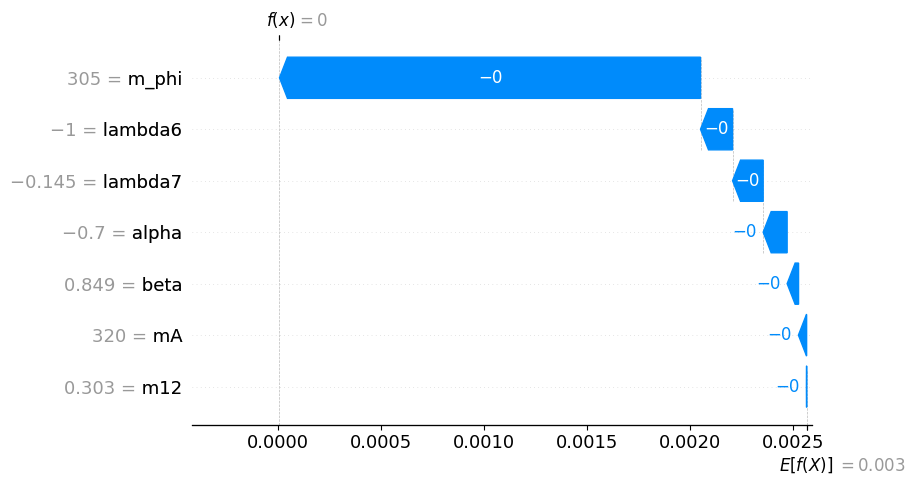

In [141]:
import shap

print(np.max(y_test))
# Elige un índice específico del conjunto de prueba para inspeccionar
indice_a_analizar = 1758

# Crea el objeto SHAP Explanation completo, especificando feature_names claramente
shap_explanation = shap.Explanation(
    values=shap_values[indice_a_analizar]*1,
    base_values=explainer.expected_value*1,
    data=X_test_subset_original[indice_a_analizar],
    feature_names=PARAM_COLS
)

# Genera un gráfico waterfall correctamente escalado
shap.plots.waterfall(shap_explanation, max_display=10, show=True)


## resultado secundario

En este intervalo especial, beta posee 2 puntos en donde presenta una gran cantidad de variacion;
dado que ahora tenemos un intervalo optimo para $m_\phi$ lo tomaremos y expandiremos un poco en conjunto con utilizar el orden de importancia de las variables para asi decidir la cantidad de precision a cada variable

Llamese a las siguientes `runs` como `eta_runs`

## Modelos alternativos

Desempeño del Modelo Alternativo (Gradient Boosting):
  R²: 0.9835
  RMSE: 0.0000


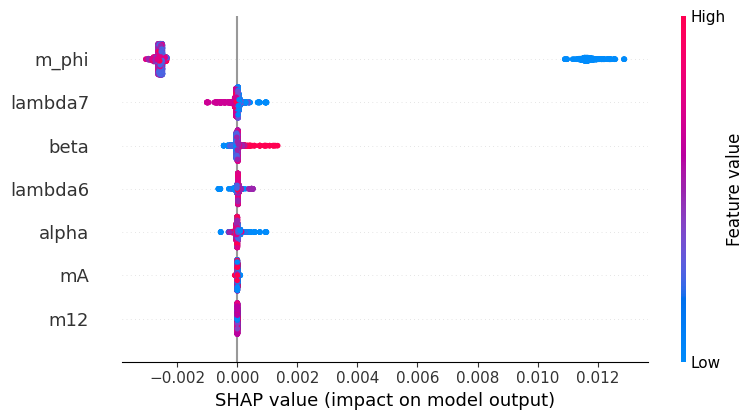

In [36]:
# %% Misión 6: El Amuleto de la Robustez – Modelo Alternativo (Gradient Boosting Regressor)
# Objetivo: Entrenar y evaluar un modelo alternativo (Gradient Boosting) para comparar su desempeño
# y calcular los valores SHAP, para confirmar que los insights obtenidos sean consistentes.

import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Parámetros ajustables para el modelo alternativo
N_ESTIMATORS = 100         # Número de estimadores
MAX_DEPTH = 3              # Profundidad máxima de cada árbol
LEARNING_RATE = 0.1        # Tasa de aprendizaje
RANDOM_STATE_MODEL = 42    # Semilla para reproducibilidad

try:
    # Entrenar el modelo de Gradient Boosting Regressor
    gb_model = GradientBoostingRegressor(n_estimators=N_ESTIMATORS, 
                                           max_depth=MAX_DEPTH,
                                           learning_rate=LEARNING_RATE,
                                           random_state=RANDOM_STATE_MODEL)
    gb_model.fit(X_train, y_train)
    
    # Realizar predicciones en el conjunto de prueba
    y_pred_gb = gb_model.predict(X_test)
    
    # Evaluar el desempeño con R² y RMSE
    r2_gb = r2_score(y_test, y_pred_gb)
    rmse_gb = mean_squared_error(y_test, y_pred_gb)
    
    print("Desempeño del Modelo Alternativo (Gradient Boosting):")
    print(f"  R²: {r2_gb:.4f}")
    print(f"  RMSE: {rmse_gb:.4f}")
    
    # Calcular los valores SHAP utilizando TreeExplainer (optimizado para modelos de árboles)
    explainer_gb = shap.TreeExplainer(gb_model)
    shap_values_gb = explainer_gb.shap_values(X_test_subset)
    
    # Generar el gráfico summary de SHAP para interpretar la influencia de cada parámetro
    shap.summary_plot(shap_values_gb, X_test_subset, feature_names=PARAM_COLS)
    
    # Opcional: Guardar el gráfico SHAP summary como imagen
    # plt.savefig("shap_summary_gb.png", dpi=300)
    
except Exception as e:
    print("Se produjo un error durante el entrenamiento o evaluación del modelo alternativo:")
    print(e)
